In [3]:
!pip install roboflow ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.6/324.6 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 98.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 8.0 MB/s eta 0:00:00


In [4]:
from roboflow import Roboflow

rf = Roboflow(api_key="4UjQu625Djlx7XVJFYNx") # ye aapki screen wali key hai
project = rf.workspace("faisal-qureshi").project("manhole-qkkhb-ylyd8")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Manhole-1 in yolov8:: 100%|██████████| 1662/1662 [00:00<00:00, 5664.28it/s]


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [5]:
from  ultralytics import YOLO

In [6]:
model = YOLO('yolov8n.pt')

In [7]:
model.train(data=f"{dataset.location}/data.yaml",epochs=25 ,imgsz=640)

Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Manhole-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=None, opset=None, optimize=False, optimize

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79a49bdf0750>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [11]:
from IPython.display import Image

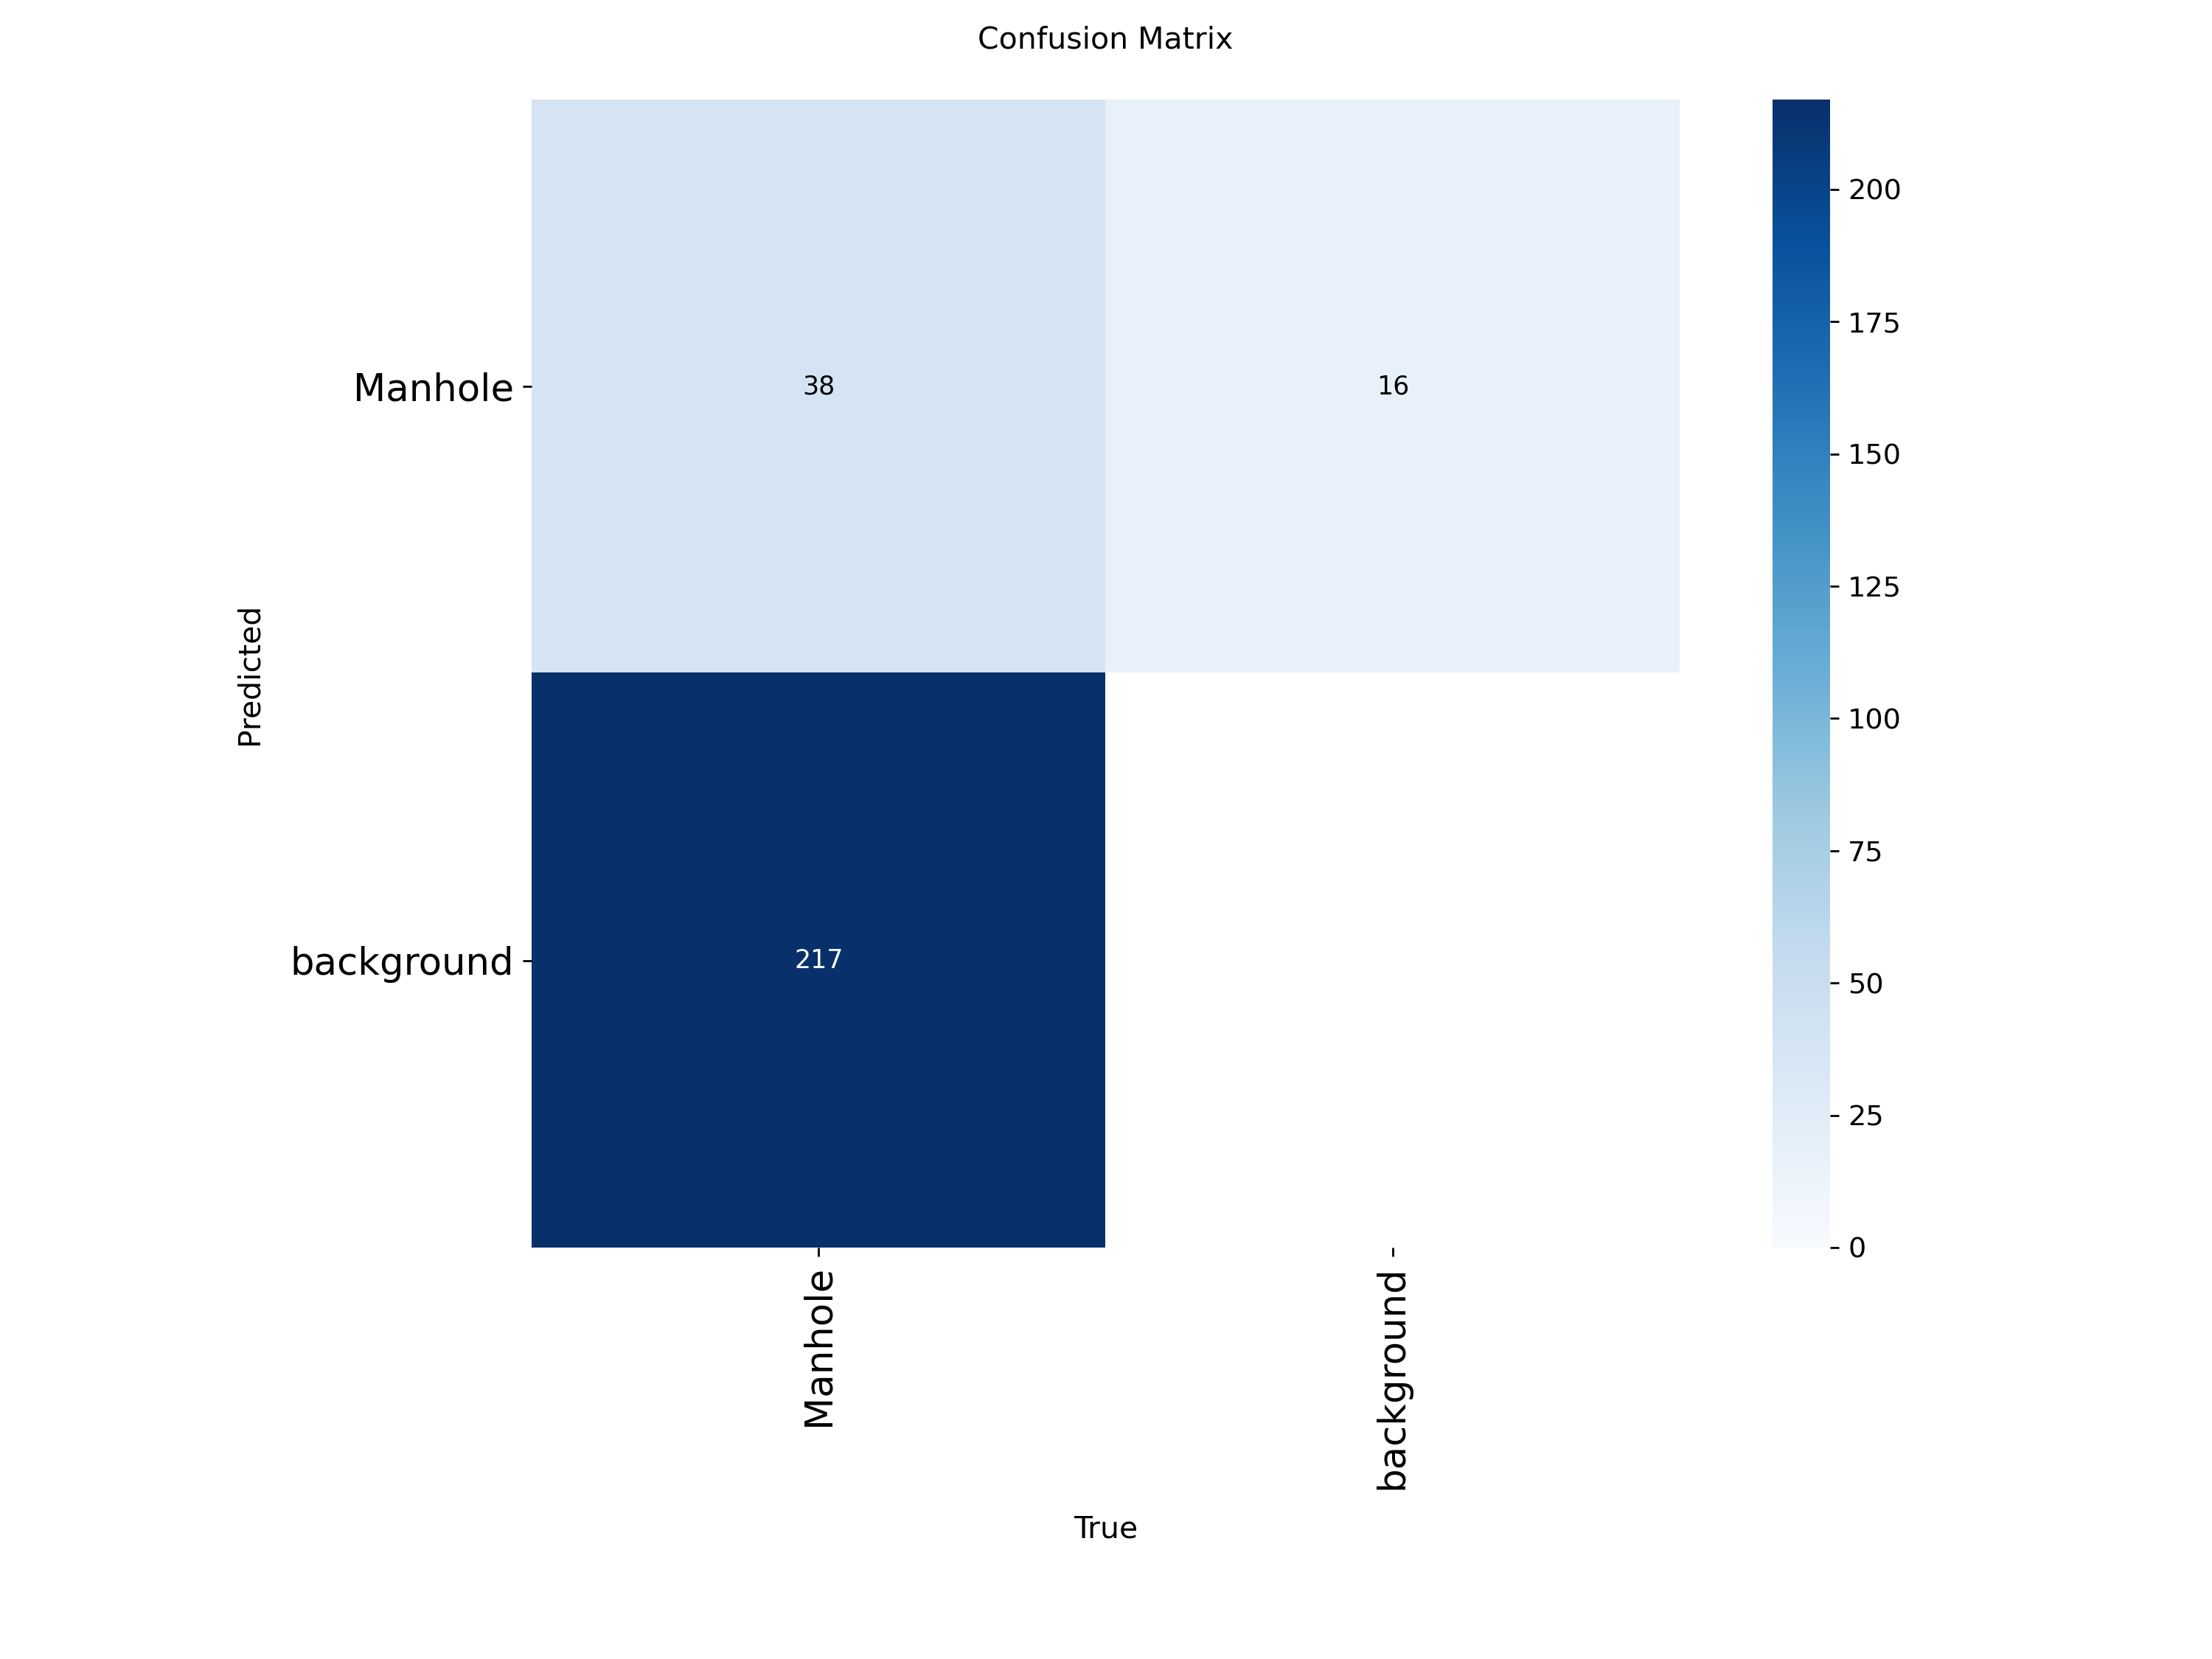

In [12]:
Image ('/content/runs/detect/train/confusion_matrix.png')

In [15]:
model.predict(source=f"{dataset.location}/test/images", save = True)


image 1/83 /content/Manhole-1/test/images/803_20_00f728f3-3915-4fde-ac32-56347c01d474_jpeg.rf.761e463d5457548ce6c67f9b319c7e6d.jpg: 640x640 (no detections), 7.0ms
image 2/83 /content/Manhole-1/test/images/803_20_02a2ee3f-7123-4b7c-b64e-0ee57bc61ecf_jpeg.rf.c4adfc5d4a294b21828db22b41dd84f1.jpg: 640x640 1 Manhole, 7.6ms
image 3/83 /content/Manhole-1/test/images/803_20_0acb6944-4c1b-4737-9d35-f06e689912f0_jpeg.rf.cd9759507b1243d66f2dee2b2a7328f7.jpg: 640x640 1 Manhole, 7.2ms
image 4/83 /content/Manhole-1/test/images/803_20_10901312-aded-4120-a4e8-efc4dcf70d02_jpeg.rf.983188602e500c668e8db0fc9fe2beaf.jpg: 640x640 1 Manhole, 7.2ms
image 5/83 /content/Manhole-1/test/images/803_20_13d7fa1f-a8ea-4490-a78f-d098570e352c_jpeg.rf.a75326752d5ef8c489929886026f0e64.jpg: 640x640 (no detections), 7.1ms
image 6/83 /content/Manhole-1/test/images/803_20_14229e29-c500-4f3e-8012-32ba9c2dc491_jpeg.rf.704b9e0c63402f1b65f8be5fb2bbb0a0.jpg: 640x640 (no detections), 7.3ms
image 7/83 /content/Manhole-1/test/imag

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 depth: None
 keypoints: None
 masks: None
 names: {0: 'Manhole'}
 obb: None
 orig_img: array([[[150, 149, 145],
         [149, 148, 144],
         [167, 166, 162],
         ...,
         [182, 178, 177],
         [157, 153, 152],
         [193, 189, 188]],
 
        [[143, 142, 138],
         [140, 139, 135],
         [155, 154, 150],
         ...,
         [158, 154, 153],
         [165, 161, 160],
         [187, 183, 182]],
 
        [[141, 140, 136],
         [135, 134, 130],
         [147, 146, 142],
         ...,
         [155, 151, 150],
         [183, 179, 178],
         [177, 173, 172]],
 
        ...,
 
        [[172, 172, 172],
         [165, 165, 165],
         [167, 167, 167],
         ...,
         [180, 181, 179],
         [176, 177, 175],
         [179, 180, 178]],
 
        [[153, 153, 153],
         [155, 155, 155],
         [159, 159, 159],
         ...,
    

In [17]:
from IPython.display import Image
import glob

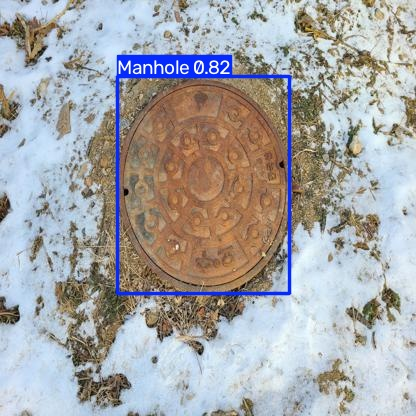

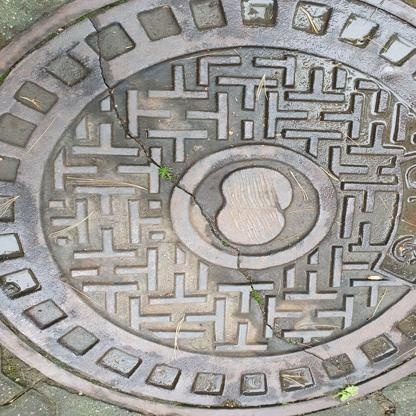

In [20]:
for img_path in glob.glob('/content/runs/detect/predict/*.jpg')[:2]:
  display(Image(filename=img_path))

##**SUMMARY**

Karachi mahole Detection Project
  **Dataset**: 580 images (Roboflow) - Manhole Class
  **Model**  : YOLOv8n - 25 epochs-Colab GPU **Result** : 82% confidence pe detect karraha h
  **Files**  :best.pt,confusion_matrix.png,results.png - sab ban gaya

---

